In [2]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from importlib import reload

import core.simulator, core.geometry, core.membrane
import core.concentration, core.registry, core.ficks
import core.analysis, core.transporter

reload(core.simulator); reload(core.geometry); reload(core.membrane)
reload(core.concentration); reload(core.registry); reload(core.ficks)
reload(core.analysis); reload(core.transporter)

from core.simulator     import Simulator
from core.geometry      import BoxGeometry, WallConfig
from core.membrane      import Membrane
from core.concentration import ConcentrationField, FirstPassageTracker
from core.registry      import Registry
from core.ficks         import FicksSolver
from core.analysis      import summarise, print_summary

print("imports ok")


imports ok


In [7]:

# ── 1. Parameters ─────────────────────────────────────────────────────────────

DRUG_NAME   = "ibuprofen"
TISSUE_NAME = "blood_brain_barrier"
N_PARTICLES = 500
N_STEPS     = 50000        
N_ENSEMBLE  = 50
DT          = 0.0005
DOSE_uM     = 10.0


# ── 2. Load drug / tissue / D_eff ─────────────────────────────────────────────

drug   = Registry.load_drug(DRUG_NAME)
tissue = Registry.load_tissue(TISSUE_NAME)
D      = Registry.compute_D_eff(drug, tissue)

print(f"Drug:            {drug.name} ({drug.drugbank_id})")
print(f"Tissue:          {tissue.name}")
print(f"MW:              {drug.MW} Da")
print(f"logP:            {drug.logP}")
print(f"pKa:             {drug.pKa}")
print(f"Protein binding: {drug.protein_binding*100:.0f}%")
print(f"D_eff:           {D:.3e} m²/s")
print(f"P-gp expression: {tissue.get_expression_scale('ABCB1'):.4f}")


# ── 3. Build simulation objects ───────────────────────────────────────────────

half = tissue.box_size / 2

box = BoxGeometry(
    bounds=[(-half, half)] * 3,
    walls={
        "z_lo": WallConfig(mode="reflect"),
        "z_hi": WallConfig(mode="absorb"),
        "x_lo": WallConfig(mode="reflect"),
        "x_hi": WallConfig(mode="reflect"),
        "y_lo": WallConfig(mode="reflect"),
        "y_hi": WallConfig(mode="reflect"),
    }
)

membrane = Membrane(
    axis=2, position=0.0,
    Papp_ms=tissue.permeability,
    D_eff=D, dt=DT,
)

conc = ConcentrationField(box_size=tissue.box_size, n_voxels=40)

tracker = FirstPassageTracker(
    axis=2,
    threshold=tissue.box_size * 0.45,
    dt=DT,
    n_particles=N_PARTICLES,
)

pgp = Registry.make_transporter_for_tissue(
    gene="ABCB1", tissue=tissue, drug=drug,
    D_eff=D, dt=DT,
    Km_um=10.0, Vmax_ms=3e-9,
    membrane_position=0.0, membrane_side="left",
    n_particles=N_PARTICLES, 
    dose_uM=DOSE_uM,
)

# FIX 1: pass geometry and membrane into the simulator
sim = Simulator(
    n_particles=N_PARTICLES, D=D, dt=DT,
    geometry=box,
    membrane=membrane,
    concentration_field=conc, fpt_tracker=tracker,
    transporters=[pgp],
)

print(f"\nMembrane P_cross:     {membrane.permeability:.6f}")
print(f"Step sigma:           {np.sqrt(2*D*DT)*1e9:.4f} nm")
print(f"Box size:             {tissue.box_size*1e6:.1f} μm")
print(f"FPT threshold:        {tracker.threshold*1e6:.1f} μm")


# ── 4. Ensemble run (for MSD) ─────────────────────────────────────────────────

print(f"\nRunning ensemble ({N_ENSEMBLE} runs × {N_STEPS} steps)...")
all_msd = []

for i in range(N_ENSEMBLE):
    if i % 10 == 0:
        print(f"  Run {i + 10}/{N_ENSEMBLE}...")
    sim.reset()
    sim.seed_left_half(half)
    sim.run(n_steps=N_STEPS)
    all_msd.append(sim.get_msd())

all_msd = np.array(all_msd)
msd_result = {
    "mean": np.nanmean(all_msd, axis=0),
    "std":  np.nanstd(all_msd, axis=0),
    "time": np.arange(N_STEPS + 1) * DT,
}

print("Ensemble MSD collected.")


# ── 5. Main simulation ────────────────────────────────────────────────────────

print("\nRunning main simulation...")
sim.reset()
sim.seed_left_half(half)
sim.run(n_steps=N_STEPS)

print(f"Done.")
print(f"  Particles arrived at threshold: {len(tracker.fpt)}")
print(f"  Membrane crossings (internal):  {membrane.n_crossings}")
print(f"  Absorbed at z_hi:  {box.n_absorbed['z_hi']}")
print(f"  Active particles remaining:     {box.active_mask.sum()}")


# ── 6. Diagnostics ────────────────────────────────────────────────────────────

step1 = np.abs(np.array(sim.history[1]) - np.array(sim.history[0]))
print(f"\nMean step size:    {step1.mean()*1e9:.4f} nm")
print(f"Expected sigma:    {np.sqrt(2*D*DT)*1e9:.4f} nm")
print(f"Ratio:             {step1.mean() / np.sqrt(2*D*DT):.4f}  (expect ~0.80)")

times_pos = tracker.get_times()
times_pos = times_pos[times_pos > 0]
print(f"\nFPT > 0:           {len(times_pos)}")
if len(times_pos) > 0:
    print(f"Min FPT:           {times_pos.min():.4f} s")
    print(f"Median FPT:        {np.median(times_pos):.4f} s")
print(f"Internal membrane crossing rate: {membrane.crossing_rate:.6f}")
print(f"  Absorbed at z_hi:                 {box.n_absorbed['z_hi']}")


# ── 7. Summary ────────────────────────────────────────────────────────────────

summary = summarise(
    drug=drug, tissue=tissue, D_eff=D,
    msd_result=msd_result, membrane=membrane,
    fpt_tracker=tracker,
)
print_summary(summary)


Drug:            ibuprofen (DB01050)
Tissue:          blood_brain_barrier
MW:              206.2808 Da
logP:            3.97
pKa:             4.91
Protein binding: 99%
D_eff:           8.461e-13 m²/s
P-gp expression: 0.0905

Membrane P_cross:     0.004309
Step sigma:           29.0878 nm
Box size:             20.0 μm
FPT threshold:        9.0 μm

Running ensemble (50 runs × 50000 steps)...
  Run 10/50...
  Run 20/50...
  Run 30/50...
  Run 40/50...
  Run 50/50...
Ensemble MSD collected.

Running main simulation...
Done.
  Particles arrived at threshold: 2
  Membrane crossings (internal):  58
  Absorbed at z_hi:  1
  Active particles remaining:     499

Mean step size:    23.3278 nm
Expected sigma:    29.0878 nm
Ratio:             0.8020  (expect ~0.80)

FPT > 0:           2
Min FPT:           21.6915 s
Median FPT:        21.9850 s
Internal membrane crossing rate: 0.004660
  Absorbed at z_hi:                 1
MatchaBrownie — Simulation Summary
  Drug:          ibuprofen  (DB01050)
  Ti

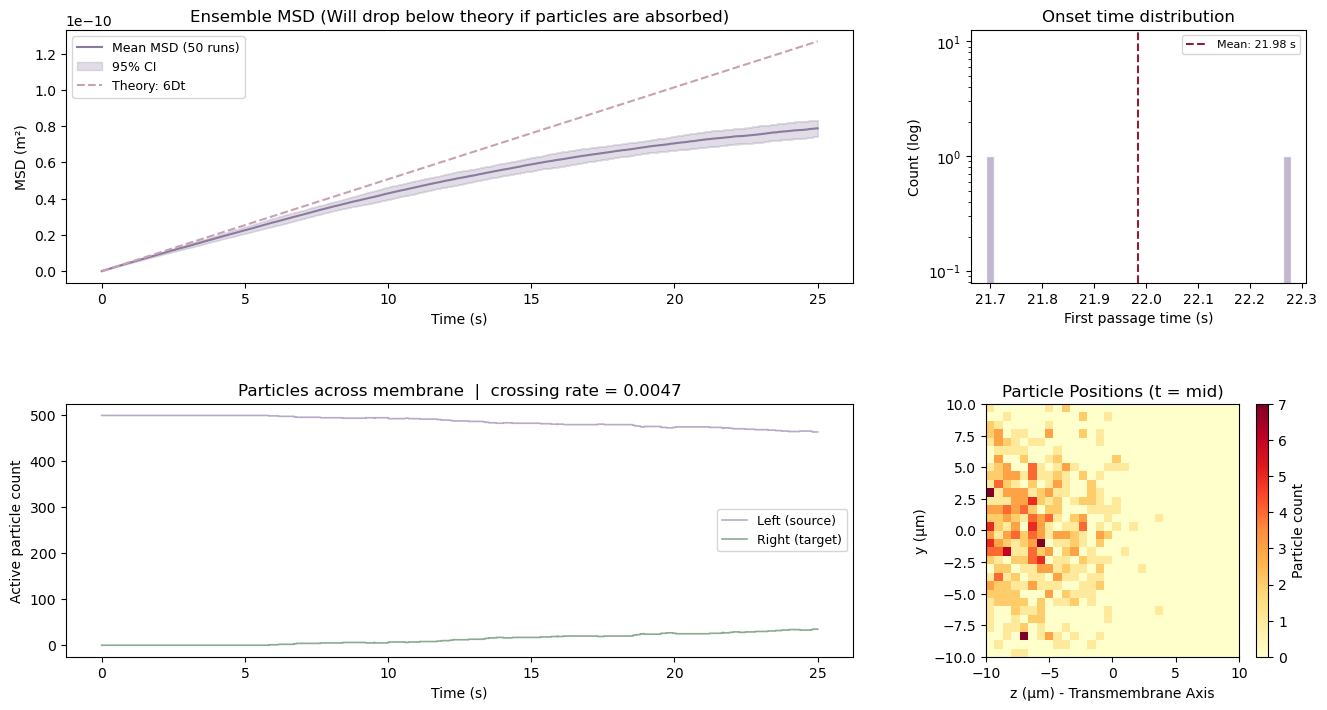

figure saved → MatchaBrownie_output.png


In [8]:
# ── 8. Figures ────────────────────────────────────────────────────────────────

from matplotlib.colors import LogNorm

fig = plt.figure(figsize=(16, 13))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.35)
half_um = half * 1e6

# 8a. Ensemble MSD (Note: Bends downward if sink condition is active)
ax1 = fig.add_subplot(gs[0, :2])
t = msd_result["time"]
ax1.plot(t, msd_result["mean"], color='#8b7a9e', lw=1.5, label=f'Mean MSD ({N_ENSEMBLE} runs)')
ax1.fill_between(t,
                 msd_result["mean"] - 1.96 * msd_result["std"],
                 msd_result["mean"] + 1.96 * msd_result["std"],
                 alpha=0.25, color='#8b7a9e', label='95% CI')
ax1.plot(t, 6 * D * t, '--', color='#c9a0b4', lw=1.5, label='Theory: 6Dt')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('MSD (m²)')
ax1.set_title('Ensemble MSD (Will drop below theory if particles are absorbed)')
ax1.legend(fontsize=9)

# 8b. Onset distribution
ax2 = fig.add_subplot(gs[0, 2])
if len(times_pos) > 0:
    ax2.hist(times_pos, bins=40, color='#b8a9c9', edgecolor='white', alpha=0.85)
    if summary.fpt_mean:
        ax2.axvline(summary.fpt_mean, color='#8b2035', lw=1.5, linestyle='--',
                    label=f"Mean: {summary.fpt_mean:.2f} s")
    ax2.set_yscale('log')
ax2.set_xlabel('First passage time (s)')
ax2.set_ylabel('Count (log)')
ax2.set_title('Onset time distribution')
ax2.legend(fontsize=8)

# 8c. Membrane crossing
ax3 = fig.add_subplot(gs[1, :2])
history_arr = np.array(sim.history)
active_arr  = np.array(sim._active_history)
# count only active particles on each side
left  = np.sum((history_arr[:, :, 2] <  0) & active_arr, axis=1)
right = np.sum((history_arr[:, :, 2] >= 0) & active_arr, axis=1)
time_axis = np.arange(len(left)) * DT
ax3.plot(time_axis, left,  color='#b8a9c9', lw=1.2, label='Left (source)')
ax3.plot(time_axis, right, color='#8aab8e', lw=1.2, label='Right (target)')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Active particle count')
ax3.set_title(f'Particles across membrane  |  crossing rate = {membrane.crossing_rate:.4f}')
ax3.legend(fontsize=9)

# 8d. Concentration field (Snapshot at Halfway Point)
ax4 = fig.add_subplot(gs[1, 2])
mid_idx = len(sim.history) // 2
mid_pos = sim.history[mid_idx]
mid_mask = sim._active_history[mid_idx]
active_pos = mid_pos[mid_mask]

# 2D Histogram on the Y-Z plane to match Fick's perspective
H, zedges, yedges = np.histogram2d(
    active_pos[:, 2], active_pos[:, 1],
    bins=30, range=[[-half, half], [-half, half]]
)
im = ax4.imshow(H.T, cmap='YlOrRd', origin='lower',
                extent=[-half_um, half_um, -half_um, half_um])
plt.colorbar(im, ax=ax4, label='Particle count')
ax4.set_xlabel('z (μm) - Transmembrane Axis')
ax4.set_ylabel('y (μm)')
ax4.set_title('Particle Positions (t = mid)')

plt.savefig("MatchaBrownie_output.png", dpi=150, bbox_inches="tight")
plt.show()
print("figure saved → MatchaBrownie_output.png")

In [3]:

# ── 1. Parameters ─────────────────────────────────────────────────────────────

DRUG_NAME   = "caffeine"
TISSUE_NAME = "intestine"
N_PARTICLES = 1000
N_STEPS     = 20000        
N_ENSEMBLE  = 50
DT          = 0.0005
DOSE_uM     = 10.0


# ── 2. Load drug / tissue / D_eff ─────────────────────────────────────────────

drug   = Registry.load_drug(DRUG_NAME)
tissue = Registry.load_tissue(TISSUE_NAME)
D      = Registry.compute_D_eff(drug, tissue)

print(f"Drug:            {drug.name} ({drug.drugbank_id})")
print(f"Tissue:          {tissue.name}")
print(f"MW:              {drug.MW} Da")
print(f"logP:            {drug.logP}")
print(f"pKa:             {drug.pKa}")
print(f"Protein binding: {drug.protein_binding*100:.0f}%")
print(f"D_eff:           {D:.3e} m²/s")
print(f"P-gp expression: {tissue.get_expression_scale('ABCB1'):.4f}")


# ── 3. Build simulation objects ───────────────────────────────────────────────

half = tissue.box_size / 2

box = BoxGeometry(
    bounds=[(-half, half)] * 3,
    walls={
        "z_lo": WallConfig(mode="reflect"),
        "z_hi": WallConfig(mode="absorb"),
        "x_lo": WallConfig(mode="reflect"),
        "x_hi": WallConfig(mode="reflect"),
        "y_lo": WallConfig(mode="reflect"),
        "y_hi": WallConfig(mode="reflect"),
    }
)

membrane = Membrane(
    axis=2, position=0.0,
    Papp_ms=tissue.permeability,
    D_eff=D, dt=DT,
)

conc = ConcentrationField(box_size=tissue.box_size, n_voxels=40)

tracker = FirstPassageTracker(
    axis=2,
    threshold=tissue.box_size * 0.45,
    dt=DT,
    n_particles=N_PARTICLES,
)

pgp = Registry.make_transporter_for_tissue(
    gene="ABCB1", tissue=tissue, drug=drug,
    D_eff=D, dt=DT,
    Km_um=10.0, Vmax_ms=3e-9,
    membrane_position=0.0, membrane_side="left",
    n_particles=N_PARTICLES, 
    dose_uM=DOSE_uM,
)

# FIX 1: pass geometry and membrane into the simulator
sim = Simulator(
    n_particles=N_PARTICLES, D=D, dt=DT,
    geometry=box,
    membrane=membrane,
    concentration_field=conc, fpt_tracker=tracker,
    transporters=[pgp],
)

print(f"\nMembrane P_cross:     {membrane.permeability:.6f}")
print(f"Step sigma:           {np.sqrt(2*D*DT)*1e9:.4f} nm")
print(f"Box size:             {tissue.box_size*1e6:.1f} μm")
print(f"FPT threshold:        {tracker.threshold*1e6:.1f} μm")


# ── 4. Ensemble run (for MSD) ─────────────────────────────────────────────────

print(f"\nRunning ensemble ({N_ENSEMBLE} runs × {N_STEPS} steps)...")
all_msd = []

for i in range(N_ENSEMBLE):
    if i % 10 == 0:
        print(f"  Run {i + 10}/{N_ENSEMBLE}...")
    sim.reset()
    sim.seed_left_half(half)
    sim.run(n_steps=N_STEPS)
    all_msd.append(sim.get_msd())

all_msd = np.array(all_msd)
msd_result = {
    "mean": np.nanmean(all_msd, axis=0),
    "std":  np.nanstd(all_msd, axis=0),
    "time": np.arange(N_STEPS + 1) * DT,
}

print("Ensemble MSD collected.")


# ── 5. Main simulation ────────────────────────────────────────────────────────

print("\nRunning main simulation...")
sim.reset()
sim.seed_left_half(half)
sim.run(n_steps=N_STEPS)

print(f"Done.")
print(f"  Particles arrived at threshold: {len(tracker.fpt)}")
print(f"  Membrane crossings (internal):  {membrane.n_crossings}")
print(f"  Absorbed at z_hi:  {box.n_absorbed['z_hi']}")
print(f"  Active particles remaining:     {box.active_mask.sum()}")


# ── 6. Diagnostics ────────────────────────────────────────────────────────────

step1 = np.abs(np.array(sim.history[1]) - np.array(sim.history[0]))
print(f"\nMean step size:    {step1.mean()*1e9:.4f} nm")
print(f"Expected sigma:    {np.sqrt(2*D*DT)*1e9:.4f} nm")
print(f"Ratio:             {step1.mean() / np.sqrt(2*D*DT):.4f}  (expect ~0.80)")

times_pos = tracker.get_times()
times_pos = times_pos[times_pos > 0]
print(f"\nFPT > 0:           {len(times_pos)}")
if len(times_pos) > 0:
    print(f"Min FPT:           {times_pos.min():.4f} s")
    print(f"Median FPT:        {np.median(times_pos):.4f} s")
print(f"Internal membrane crossing rate: {membrane.crossing_rate:.6f}")
print(f"  Absorbed at z_hi:                 {box.n_absorbed['z_hi']}")


# ── 7. Summary ────────────────────────────────────────────────────────────────

summary = summarise(
    drug=drug, tissue=tissue, D_eff=D,
    msd_result=msd_result, membrane=membrane,
    fpt_tracker=tracker,
)
print_summary(summary)


Drug:            caffeine (DB00201)
Tissue:          intestine
MW:              194.1906 Da
logP:            -0.07
pKa:             10.4
Protein binding: 36%
D_eff:           1.692e-10 m²/s
P-gp expression: 0.6930
⚠ WARNING: Membrane permeability for axis 2 clipped to 1.0. Results will be timestep-dependent. Consider reducing dt.

Membrane P_cross:     1.000000
Step sigma:           411.3499 nm
Box size:             25.0 μm
FPT threshold:        11.2 μm

Running ensemble (50 runs × 20000 steps)...
  Run 10/50...


c:\Users\Nandan Thakare\OneDrive\Documents\drugnandan\notebooks\..\core\simulator.py:210: RuntimeWarning: Mean of empty slice
  return np.nanmean(disp_sq_masked, axis=1)


  Run 20/50...
  Run 30/50...
  Run 40/50...
  Run 50/50...
Ensemble MSD collected.

Running main simulation...
Done.
  Particles arrived at threshold: 995
  Membrane crossings (internal):  51730
  Absorbed at z_hi:  996
  Active particles remaining:     4

Mean step size:    315.6064 nm
Expected sigma:    411.3499 nm
Ratio:             0.7672  (expect ~0.80)

FPT > 0:           995
Min FPT:           0.1625 s
Median FPT:        1.2270 s
Internal membrane crossing rate: 1.000000
  Absorbed at z_hi:                 996
MatchaBrownie — Simulation Summary
  Drug:          caffeine  (DB00201)
  Tissue:        intestine
  D_eff:         1.692e-10 m²/s
-----------------------------------------------------
  Particles total:          1000
  Particles arrived:        995
  Membrane crossing rate:   1.0000
-----------------------------------------------------
  Mean onset time:          1.694 s
  Median onset time:        1.227 s
  Std deviation:            1.408 s
  95% CI (bootstrap):       [

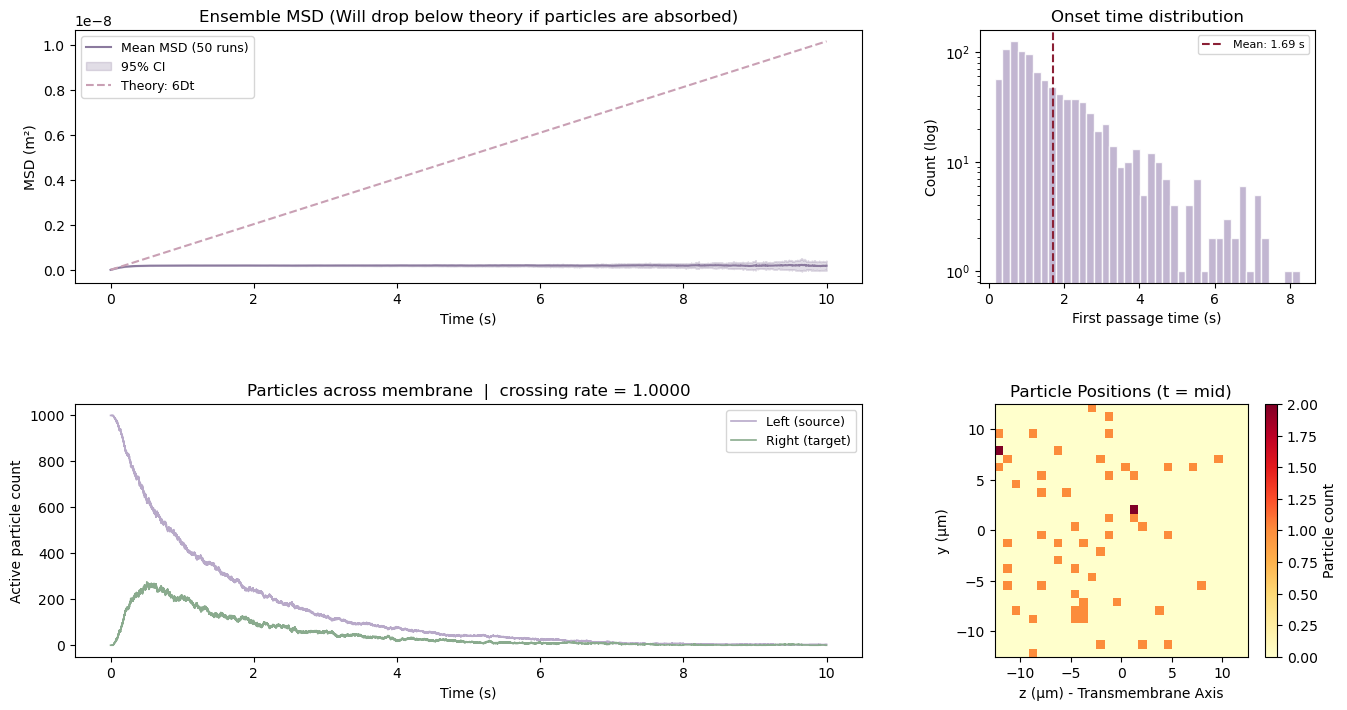

figure saved → MatchaBrownie_output.png


In [4]:
# ── 8. Figures ────────────────────────────────────────────────────────────────

from matplotlib.colors import LogNorm

fig = plt.figure(figsize=(16, 13))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.35)
half_um = half * 1e6

# 8a. Ensemble MSD (Note: Bends downward if sink condition is active)
ax1 = fig.add_subplot(gs[0, :2])
t = msd_result["time"]
ax1.plot(t, msd_result["mean"], color='#8b7a9e', lw=1.5, label=f'Mean MSD ({N_ENSEMBLE} runs)')
ax1.fill_between(t,
                 msd_result["mean"] - 1.96 * msd_result["std"],
                 msd_result["mean"] + 1.96 * msd_result["std"],
                 alpha=0.25, color='#8b7a9e', label='95% CI')
ax1.plot(t, 6 * D * t, '--', color='#c9a0b4', lw=1.5, label='Theory: 6Dt')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('MSD (m²)')
ax1.set_title('Ensemble MSD (Will drop below theory if particles are absorbed)')
ax1.legend(fontsize=9)

# 8b. Onset distribution
ax2 = fig.add_subplot(gs[0, 2])
if len(times_pos) > 0:
    ax2.hist(times_pos, bins=40, color='#b8a9c9', edgecolor='white', alpha=0.85)
    if summary.fpt_mean:
        ax2.axvline(summary.fpt_mean, color='#8b2035', lw=1.5, linestyle='--',
                    label=f"Mean: {summary.fpt_mean:.2f} s")
    ax2.set_yscale('log')
ax2.set_xlabel('First passage time (s)')
ax2.set_ylabel('Count (log)')
ax2.set_title('Onset time distribution')
ax2.legend(fontsize=8)

# 8c. Membrane crossing
ax3 = fig.add_subplot(gs[1, :2])
history_arr = np.array(sim.history)
active_arr  = np.array(sim._active_history)
# count only active particles on each side
left  = np.sum((history_arr[:, :, 2] <  0) & active_arr, axis=1)
right = np.sum((history_arr[:, :, 2] >= 0) & active_arr, axis=1)
time_axis = np.arange(len(left)) * DT
ax3.plot(time_axis, left,  color='#b8a9c9', lw=1.2, label='Left (source)')
ax3.plot(time_axis, right, color='#8aab8e', lw=1.2, label='Right (target)')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Active particle count')
ax3.set_title(f'Particles across membrane  |  crossing rate = {membrane.crossing_rate:.4f}')
ax3.legend(fontsize=9)

# 8d. Concentration field (Snapshot at Halfway Point)
ax4 = fig.add_subplot(gs[1, 2])
mid_idx = len(sim.history) // 2
mid_pos = sim.history[mid_idx]
mid_mask = sim._active_history[mid_idx]
active_pos = mid_pos[mid_mask]

# 2D Histogram on the Y-Z plane to match Fick's perspective
H, zedges, yedges = np.histogram2d(
    active_pos[:, 2], active_pos[:, 1],
    bins=30, range=[[-half, half], [-half, half]]
)
im = ax4.imshow(H.T, cmap='YlOrRd', origin='lower',
                extent=[-half_um, half_um, -half_um, half_um])
plt.colorbar(im, ax=ax4, label='Particle count')
ax4.set_xlabel('z (μm) - Transmembrane Axis')
ax4.set_ylabel('y (μm)')
ax4.set_title('Particle Positions (t = mid)')

plt.savefig("MatchaBrownie_output.png", dpi=150, bbox_inches="tight")
plt.show()
print("figure saved → MatchaBrownie_output.png")